# Non-Linear Data — Polynomial Regression

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error


## 2. Load data

In [2]:
df = pd.read_csv('data/iceNL.csv')
df.head()


,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


## 3. Check linearity

Plot + `corr()` first. A correlation close to 0 with a curved scatter
pattern means the relationship is **non-linear**.

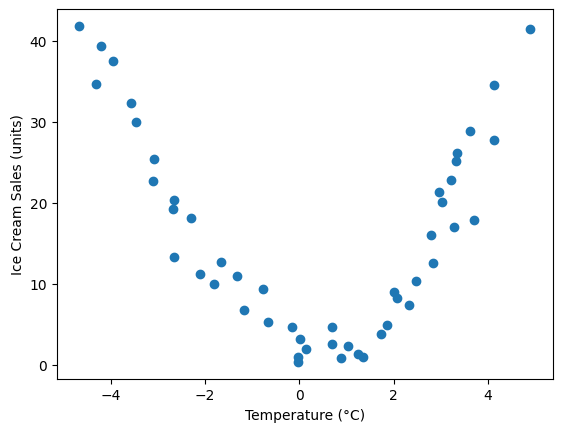

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [3]:
plt.scatter(df['Temperature (°C)'], df['Ice Cream Sales (units)'])
plt.xlabel('Temperature (°C)'); plt.ylabel('Ice Cream Sales (units)')
plt.show()

df.corr()


## 4. Define X and y, then split

In [4]:
x = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)


## 5. Plain Linear Regression (baseline — expected to underfit)

In [5]:
model = LinearRegression()
model.fit(xtrain, ytrain)

ypred_train = model.predict(xtrain)
print("Train R2:", r2_score(ytrain, ypred_train))


Train R2: 0.06579063815950037


## 6. Polynomial Features — fix the underfit

`PolynomialFeatures` expands the single feature into curve-fitting terms
(x, x²), then a normal `LinearRegression` fits a curve through them.

In [6]:
poly = PolynomialFeatures(degree=2)
xtrain_poly = poly.fit_transform(xtrain)
xtest_poly = poly.transform(xtest)

poly_model = LinearRegression()
poly_model.fit(xtrain_poly, ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 7. Evaluate — R2, MAE, RMSE on train and test

In [7]:
ypred_train = poly_model.predict(xtrain_poly)
ypred_test = poly_model.predict(xtest_poly)

print("Train R2:", r2_score(ytrain, ypred_train))
print("Test R2 :", r2_score(ytest, ypred_test))
print("Test MAE :", mean_absolute_error(ytest, ypred_test))
print("Test RMSE:", root_mean_squared_error(ytest, ypred_test))


Train R2: 0.9413665676490518
Test R2 : 0.843055137193884
Test MAE : 3.2299819836597274
Test RMSE: 3.857304297171988


## 8. Visualize the fitted curve

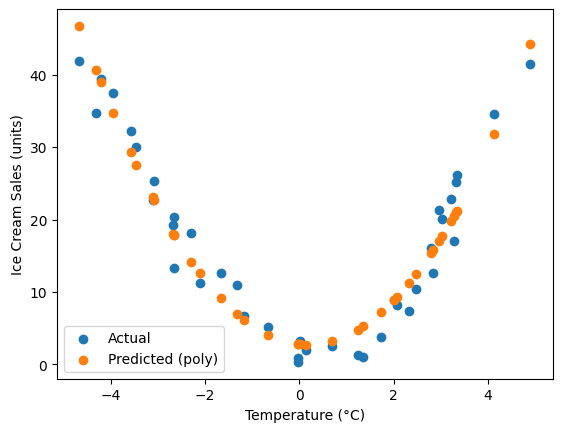

In [8]:
plt.scatter(xtrain, ytrain, label='Actual')
plt.scatter(xtrain, ypred_train, label='Predicted (poly)')
plt.xlabel('Temperature (°C)'); plt.ylabel('Ice Cream Sales (units)')
plt.legend()
plt.show()


## 9. If polynomial still underperforms — go tree-based

Decision Tree / Random Forest Regressors don't assume any specific curve
shape, so they can be a better fit for highly irregular non-linear data.